# Modèle Black-Litterman

In [11]:
# !pip install pypfopt matplotlib seaborn scipy

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.optimize import minimize

from pypfopt import black_litterman, risk_models
from pypfopt import BlackLittermanModel, EfficientFrontier
from pypfopt.risk_models import CovarianceShrinkage

np.random.seed(42)
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (13, 6)
plt.rcParams['font.size'] = 11

# Palette de couleurs pour les 5 portefeuilles
COLORS = {
    'mktcap':      '#78909C',
    'naive':       '#FF7043',
    'bl':          '#1565C0',
    'bl_ctr':      '#00BCD4',
    'risk_parity': '#2E7D32',
}
LABELS = {
    'mktcap':      'Market Cap',
    'naive':       'Max Sharpe naïf',
    'bl':          'BL Max Sharpe',
    'bl_ctr':      'BL Contraint (5-35%)',
    'risk_parity': 'Risk Parity',
}

## 1. Simulation de données de prix (GBM, 2 ans)

In [13]:
tickers = ["AAPL", "MSFT", "GOOG", "AMZN", "TSLA"]
n_assets = len(tickers)
n_days   = 504  # ~2 ans

mu_annual    = np.array([0.12, 0.14, 0.10, 0.11, 0.22])
sigma_annual = np.array([0.22, 0.24, 0.20, 0.26, 0.55])

corr = np.array([
    [1.00, 0.75, 0.65, 0.60, 0.35],
    [0.75, 1.00, 0.70, 0.65, 0.30],
    [0.65, 0.70, 1.00, 0.62, 0.28],
    [0.60, 0.65, 0.62, 1.00, 0.32],
    [0.35, 0.30, 0.28, 0.32, 1.00],
])

cov_daily = np.outer(sigma_annual, sigma_annual) * corr / 252
L = np.linalg.cholesky(cov_daily)
z = np.random.standard_normal((n_days, n_assets))
returns_daily = mu_annual / 252 + z @ L.T

dates  = pd.date_range(end='2024-12-31', periods=n_days, freq='B')
prices = pd.DataFrame(
    100 * np.exp(np.cumsum(returns_daily, axis=0)),
    index=dates, columns=tickers
)
returns_df = prices.pct_change().dropna()

# Split train / test
split        = len(prices) // 2
prices_train = prices.iloc[:split]
prices_test  = prices.iloc[split:]

print(f"Train : {prices_train.index[0].date()} → {prices_train.index[-1].date()}  ({split} jours)")
print(f"Test  : {prices_test.index[0].date()}  → {prices_test.index[-1].date()}  ({len(prices_test)} jours)")

Train : 2023-01-26 → 2024-01-12  (252 jours)
Test  : 2024-01-15  → 2024-12-31  (252 jours)


## 2. Covariance — Ledoit-Wolf vs Empirique

La covariance empirique souffre du **bruit d'estimation** : avec 252 observations et 5 actifs c'est encore gérable, mais dès qu'on passe à 20+ actifs elle devient instable.  
Ledoit-Wolf « rétrécit » (shrink) la matrice vers une cible structurée, réduisant l'erreur quadratique moyenne.

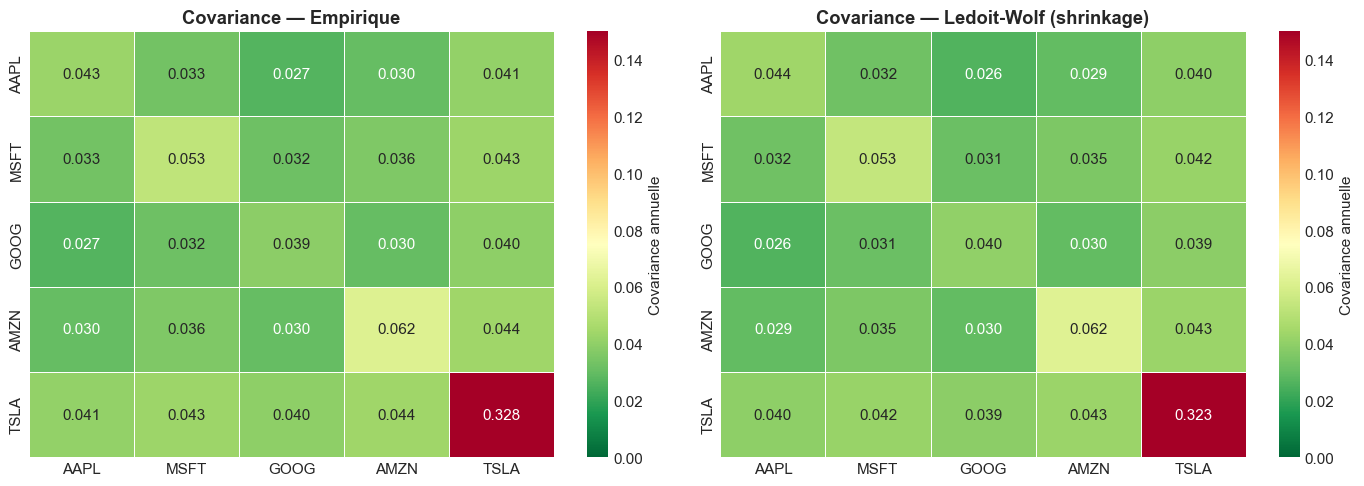

Covariance Ledoit-Wolf sélectionnée pour la suite.

Volatilités annualisées :
AAPL    20.9
MSFT    23.1
GOOG    20.1
AMZN    24.9
TSLA    56.8 %


In [14]:
# Covariance empirique (train uniquement — pas de data leakage)
cov_empirical = risk_models.sample_cov(prices_train, frequency=252)

# ✅ Ledoit-Wolf shrinkage
cov_lw = CovarianceShrinkage(prices_train, frequency=252).ledoit_wolf()

# Visualisation côte à côte
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, cov, title in zip(axes,
                           [cov_empirical, cov_lw],
                           ['Empirique', 'Ledoit-Wolf (shrinkage)']):
    sns.heatmap(cov, annot=True, fmt='.3f', cmap='RdYlGn_r',
                linewidths=0.5, ax=ax, vmin=0, vmax=0.15,
                cbar_kws={'label': 'Covariance annuelle'})
    ax.set_title(f'Covariance — {title}', fontweight='bold')
plt.tight_layout()
plt.show()

# On utilise Ledoit-Wolf pour la suite
cov_matrix = cov_lw
print("Covariance Ledoit-Wolf sélectionnée pour la suite.")
print("\nVolatilités annualisées :")
vols = pd.Series(np.sqrt(np.diag(cov_matrix)) * 100, index=tickers).round(1)
print(vols.to_string(), "%")

## 3. Black-Litterman — Rendements postérieurs

In [15]:
market_caps  = {"AAPL": 2800, "MSFT": 2500, "GOOG": 1600, "AMZN": 1300, "TSLA": 800}
delta = 2.5
tau   = 1 / split

prior_returns = black_litterman.market_implied_prior_returns(market_caps, delta, cov_matrix)

# Vues du gérant
#                    AAPL  MSFT  GOOG  AMZN  TSLA
P = np.array([
    [1,  0,  0,  0,  0],   # Vue 1 (absolue) : AAPL +8%
    [0,  0,  0,  0,  1],   # Vue 2 (absolue) : TSLA +15%
    [0,  1, -1,  0,  0],   # Vue 3 (relative): MSFT surperforme GOOG de 3%
])
Q = np.array([0.08, 0.15, 0.03])

bl_model = BlackLittermanModel(cov_matrix, pi=prior_returns, P=P, Q=Q, tau=tau)
rets_bl  = bl_model.bl_returns()
cov_bl   = bl_model.bl_cov()

print("Rendements : Prior → Posterior")
for t in tickers:
    print(f"  {t}: {prior_returns[t]*100:.2f}%  →  {rets_bl[t]*100:.2f}%  "
          f"({(rets_bl[t]-prior_returns[t])*100:+.2f}%)")

Rendements : Prior → Posterior
  AAPL: 8.75%  →  8.40%  (-0.35%)
  MSFT: 9.82%  →  9.87%  (+0.05%)
  GOOG: 7.93%  →  7.45%  (-0.48%)
  AMZN: 9.24%  →  9.01%  (-0.24%)
  TSLA: 16.46%  →  15.58%  (-0.88%)


## 4. Optimisation — 5 stratégies

In [16]:
# ── 1. Market Cap ──────────────────────────────────────────────────────────
total_cap = sum(market_caps.values())
w_mktcap  = {t: market_caps[t] / total_cap for t in tickers}

# ── 2. Max Sharpe naïf (covariance empirique, rendements historiques) ──────
mu_hist  = returns_df.iloc[:split].mean() * 252
ef_naive = EfficientFrontier(mu_hist, cov_empirical)
ef_naive.max_sharpe(risk_free_rate=0.04)
w_naive  = ef_naive.clean_weights()

# ── 3. BL Max Sharpe (sans contraintes) ────────────────────────────────────
ef_bl = EfficientFrontier(rets_bl, cov_bl)
ef_bl.max_sharpe(risk_free_rate=0.04)
w_bl  = ef_bl.clean_weights()

# ── 4. BL Contraint (5% ≤ w ≤ 35%) ────────────────────────────────────────
ef_bl_ctr = EfficientFrontier(rets_bl, cov_bl,
                               weight_bounds=(0.05, 0.35))  # ← contraintes ici
ef_bl_ctr.max_sharpe(risk_free_rate=0.04)
w_bl_ctr  = ef_bl_ctr.clean_weights()

# ── 5. Risk Parity (Equal Risk Contribution) ───────────────────────────────
def risk_contribution(w, cov):
    """Contribution marginale au risque de chaque actif."""
    w   = np.array(w)
    cov = np.array(cov)
    sigma = np.sqrt(w @ cov @ w)
    mrc   = cov @ w / sigma          # Contribution marginale
    rc    = w * mrc                  # Contribution absolue
    return rc

def risk_parity_objective(w, cov):
    """On minimise la variance des contributions au risque → égalité."""
    rc = risk_contribution(w, cov)
    return np.sum((rc - rc.mean()) ** 2)

cov_np = np.array(cov_matrix)
w0     = np.ones(n_assets) / n_assets
bounds = [(0.01, 1.0)] * n_assets
constraints = [{'type': 'eq', 'fun': lambda w: np.sum(w) - 1}]

result = minimize(
    risk_parity_objective, w0,
    args=(cov_np,),
    method='SLSQP',
    bounds=bounds,
    constraints=constraints,
    options={'ftol': 1e-12, 'maxiter': 1000}
)
w_rp_arr = result.x / result.x.sum()
w_rp     = dict(zip(tickers, w_rp_arr))

# ── Tableau récapitulatif ───────────────────────────────────────────────────
weights_df = pd.DataFrame({
    'Market Cap':      w_mktcap,
    'Max Sharpe naïf': w_naive,
    'BL Max Sharpe':   w_bl,
    'BL Contraint':    w_bl_ctr,
    'Risk Parity':     w_rp,
}).T

print("Poids des 5 portefeuilles (%) :")
print((weights_df * 100).round(1).to_string())

Poids des 5 portefeuilles (%) :
                 AAPL  MSFT  GOOG  AMZN  TSLA
Market Cap       31.1  27.8  17.8  14.4   8.9
Max Sharpe naïf   0.0   0.0   0.0  35.1  64.9
BL Max Sharpe    12.9  56.0   0.0  13.6  17.6
BL Contraint     23.3  35.0   5.0  19.1  17.6
Risk Parity      23.5  20.8  24.2  20.4  11.0


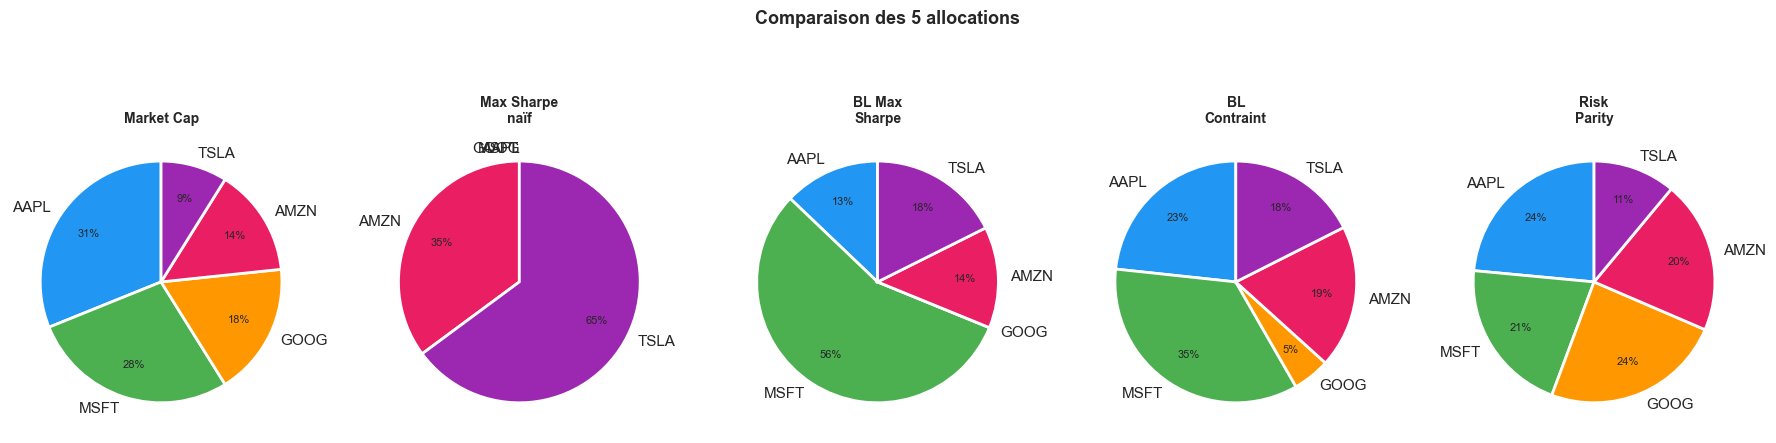


Contributions au risque — Risk Parity (doit être ~égal) :
  AAPL: 3.98%
  MSFT: 3.98%
  GOOG: 3.98%
  AMZN: 3.98%
  TSLA: 3.98%


In [17]:
fig, axes = plt.subplots(1, 5, figsize=(18, 5))
asset_colors = ['#2196F3', '#4CAF50', '#FF9800', '#E91E63', '#9C27B0']
port_list    = [w_mktcap, w_naive, w_bl, w_bl_ctr, w_rp]
port_titles  = ['Market Cap', 'Max Sharpe\nnaïf', 'BL Max\nSharpe', 'BL\nContraint', 'Risk\nParity']

for ax, title, weights in zip(axes, port_titles, port_list):
    vals = [weights[t] for t in tickers]
    wedges, texts, autotexts = ax.pie(
        vals, labels=tickers, colors=asset_colors,
        autopct=lambda p: f'{p:.0f}%' if p > 3 else '',
        startangle=90, pctdistance=0.72,
        wedgeprops=dict(edgecolor='white', linewidth=2)
    )
    for at in autotexts: at.set_fontsize(8)
    ax.set_title(title, fontweight='bold', fontsize=10)

plt.suptitle('Comparaison des 5 allocations', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# Vérification Risk Parity : contributions au risque
rc = risk_contribution(w_rp_arr, cov_np)
print("\nContributions au risque — Risk Parity (doit être ~égal) :")
for t, c in zip(tickers, rc):
    print(f"  {t}: {c*100:.2f}%")

## 5. Backtest Out-of-Sample — 5 stratégies

In [18]:
def portfolio_value(prices_df, weights_dict, initial=10000):
    w            = np.array([weights_dict[t] for t in prices_df.columns])
    rets         = prices_df.pct_change().fillna(0)
    port_returns = (rets * w).sum(axis=1)
    return initial * (1 + port_returns).cumprod()

def sharpe(values, rf=0.04/252):
    r = values.pct_change().dropna()
    return np.sqrt(252) * (r.mean() - rf) / r.std()

def max_drawdown(values):
    return ((values - values.cummax()) / values.cummax()).min()

def calmar(values):
    ann_ret = (values.iloc[-1] / values.iloc[0]) - 1
    mdd     = abs(max_drawdown(values))
    return ann_ret / mdd if mdd > 0 else np.nan

portfolios = {
    'mktcap':      w_mktcap,
    'naive':       w_naive,
    'bl':          w_bl,
    'bl_ctr':      w_bl_ctr,
    'risk_parity': w_rp,
}

values = {k: portfolio_value(prices_test, w) for k, w in portfolios.items()}

# Tableau de performance
perf = pd.DataFrame({
    'Rendement total': {k: f"{(v.iloc[-1]/10000 - 1)*100:.1f}%" for k, v in values.items()},
    'Sharpe':          {k: f"{sharpe(v):.2f}"                    for k, v in values.items()},
    'Max Drawdown':    {k: f"{max_drawdown(v)*100:.1f}%"          for k, v in values.items()},
    'Calmar':          {k: f"{calmar(v):.2f}"                     for k, v in values.items()},
}).rename(index=LABELS)

print("Performance out-of-sample :")
print(perf.to_string())

Performance out-of-sample :
                     Rendement total Sharpe Max Drawdown Calmar
Market Cap                     54.3%   2.02       -12.9%   4.20
Max Sharpe naïf                80.3%   1.67       -17.8%   4.51
BL Max Sharpe                  63.6%   2.07       -12.6%   5.05
BL Contraint (5-35%)           59.6%   2.04       -12.0%   4.97
Risk Parity                    53.4%   2.00       -12.3%   4.35


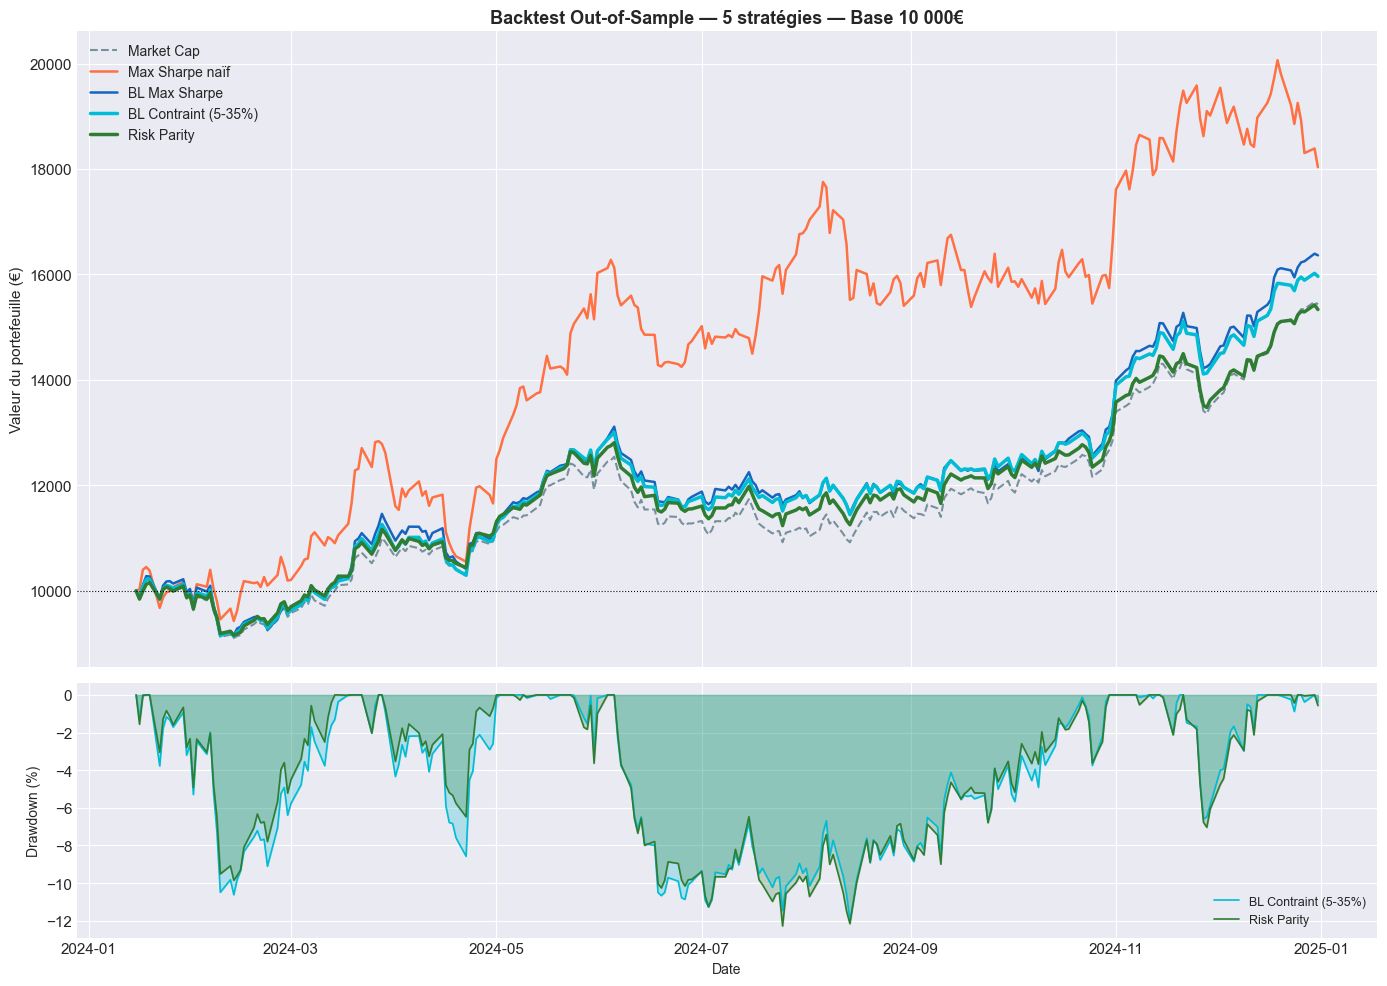

In [19]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10),
                                gridspec_kw={'height_ratios': [3, 1.2]})

#Évolution des portefeuilles
styles = {'mktcap': '--', 'naive': '-', 'bl': '-', 'bl_ctr': '-', 'risk_parity': '-'}
widths = {'mktcap': 1.5,  'naive': 1.8, 'bl': 1.8, 'bl_ctr': 2.5, 'risk_parity': 2.5}

for k, v in values.items():
    ax1.plot(v.index, v,
             label=LABELS[k],
             color=COLORS[k],
             linestyle=styles[k],
             linewidth=widths[k])

ax1.axhline(10000, color='black', linewidth=0.8, linestyle=':')
ax1.set_ylabel('Valeur du portefeuille (€)', fontsize=11)
ax1.set_title('Backtest Out-of-Sample — 5 stratégies — Base 10 000€',
              fontsize=13, fontweight='bold')
ax1.legend(fontsize=10, loc='upper left')
ax1.set_xticklabels([])

#Drawdown des 2 meilleures stratégies
for k in ['bl_ctr', 'risk_parity']:
    v  = values[k]
    dd = (v - v.cummax()) / v.cummax() * 100
    ax2.fill_between(dd.index, dd, 0, alpha=0.25, color=COLORS[k])
    ax2.plot(dd.index, dd, color=COLORS[k], linewidth=1.2, label=LABELS[k])

ax2.set_ylabel('Drawdown (%)', fontsize=10)
ax2.set_xlabel('Date', fontsize=10)
ax2.legend(fontsize=9)

plt.tight_layout()
plt.show()

## 6. Analyse des contributions au risque

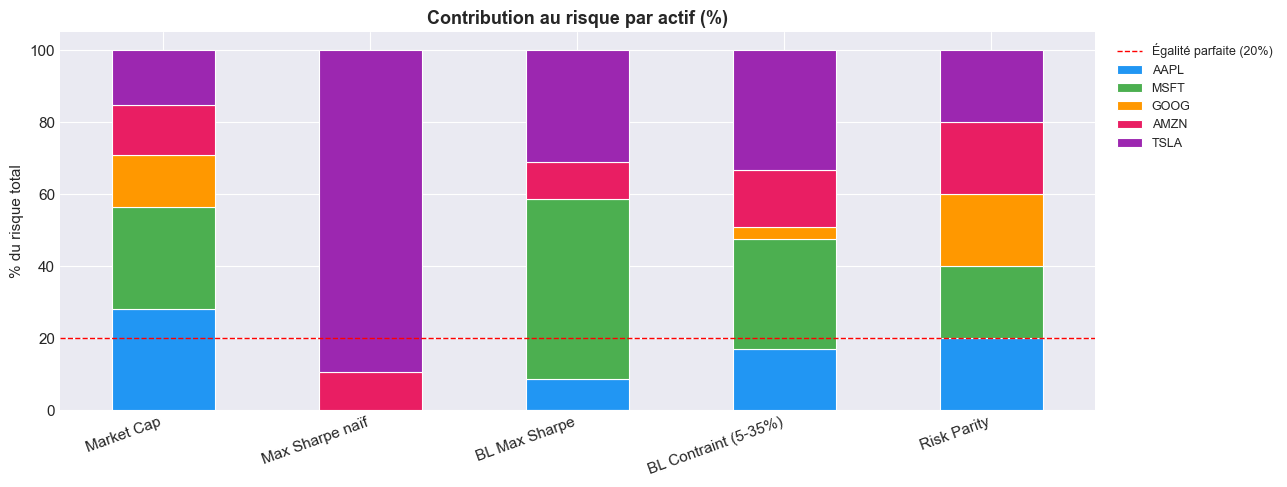

Contributions au risque (%) :
                      AAPL  MSFT  GOOG  AMZN  TSLA
Market Cap            28.2  28.2  14.6  13.8  15.1
Max Sharpe naïf        0.0   0.0   0.0  10.7  89.3
BL Max Sharpe          8.6  50.0   0.0  10.3  31.1
BL Contraint (5-35%)  17.1  30.5   3.3  15.9  33.1
Risk Parity           20.0  20.0  20.0  20.0  20.0


In [20]:
def get_risk_contributions(weights_dict, cov):
    w     = np.array([weights_dict[t] for t in tickers])
    cov_  = np.array(cov)
    sigma = np.sqrt(w @ cov_ @ w)
    mrc   = cov_ @ w / sigma
    rc    = w * mrc
    return rc / rc.sum() * 100  # En % du risque total

rc_data = pd.DataFrame({
    LABELS[k]: get_risk_contributions(w, cov_matrix)
    for k, w in portfolios.items()
}, index=tickers).T

fig, ax = plt.subplots(figsize=(13, 5))
asset_colors = ['#2196F3', '#4CAF50', '#FF9800', '#E91E63', '#9C27B0']
rc_data.plot(kind='bar', stacked=True, ax=ax, color=asset_colors,
             edgecolor='white', linewidth=0.8)
ax.axhline(20, color='red', linestyle='--', linewidth=1,
           label='Égalité parfaite (20%)')
ax.set_title('Contribution au risque par actif (%)', fontsize=13, fontweight='bold')
ax.set_ylabel('% du risque total')
ax.set_xticklabels(ax.get_xticklabels(), rotation=20, ha='right')
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
plt.tight_layout()
plt.show()

print("Contributions au risque (%) :")
print(rc_data.round(1).to_string())